In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
    Created on Thu Jul 18 2025
    
    @author: Yaning
"""

import os
import torch
import pyro
from pyro.optim import Adam
import pyro.distributions as dist
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import seaborn as sns
import pickle
from pyro.infer import SVI, Trace_ELBO
import re
import pandas as pd

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
with open('/home/yaning/Documents/Discounting/results/array_cafe_gamble.pkl', 'rb') as f:
    data = pickle.load(f)

In [ ]:
data = data.reshape(60,170,8)

In [5]:
data = torch.tensor(data)

In [6]:
data = data.to(device)

In [7]:
data.shape

torch.Size([60, 170, 8])

In [12]:
def model(data):
    num_params = 5
    num_agents = data.shape[0]
    num_trials = data.shape[1]
    # define hyper priors over model parameters
    # prior over sigma of a Gaussian is a Gamma distribution
    a = pyro.param('a', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    lam = pyro.param('lam', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    tau = pyro.sample('tau', dist.Gamma(a, a/lam).to_event(1)) # mean = a / (a/lam) = lam

    sig = pyro.deterministic('sig', 1/torch.sqrt(tau)) # Gauss sigma

    # each model parameter has a hyperprior defining group level mean
    # in the form of a Normal distribution
    m = pyro.param('m', torch.zeros(num_params, device=device))
    s = pyro.param('s', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    mu = pyro.sample('mu', dist.Normal(m, s*sig).to_event(1)) # Gauss mu, wieso s*sig?

    # in order to implement groups, where each subject is independent of the others, pyro uses so-called plates.
    # you embed what should be done for each subject into the "with pyro.plate" context
    # the plate vectorizes subjects and adds an additional dimension onto all arrays/tensors
    # i.e. p1 below will have the length num_agents
    with pyro.plate('ag_idx', num_agents):
        # draw parameters from Normal and transform (for numeric trick reasons)
        # base_dist = dist.Normal(0., 1.).expand_by([num_params]).to_event(1)
        base_dist = dist.Normal(torch.zeros(num_params, device=device), torch.ones(num_params, device=device)).to_event(1)
        # Transform via the pointwise affine mapping y = loc + scale*x (-> Neal's funnel)
        transform = dist.transforms.AffineTransform(mu, sig)

        locs = pyro.sample('locs', dist.TransformedDistribution(base_dist, [transform]))
        # print(locs.shape)


    with pyro.plate('data', num_agents*num_trials):
        a_one = locs[:,0].unsqueeze(-1).expand(-1, num_trials)
        a_two = torch.exp(locs[:,1]).unsqueeze(-1).expand(-1, num_trials)
        x_zero = torch.exp(locs[:,2]).unsqueeze(-1).expand(-1, num_trials)
        p = torch.exp(locs[:,3]).unsqueeze(-1).expand(-1, num_trials)
        beta = torch.exp(locs[:,4]).unsqueeze(-1).expand(-1, num_trials)

        sigma_rate = a_two + (a_one-a_two)/(1+(data[:,:,2]*10/x_zero)**p)
        e_mean = (data[:,:,3])/(1 + sigma_rate**2)

        # e_mean = (data[:,:,3])/(sigma_combine + 1)
        sum = e_mean + torch.tensor(20., device=device)

        softmax_args = torch.stack([beta*e_mean/sum, beta*torch.tensor(20., device=device)/sum])
        p = torch.softmax(softmax_args, dim = 0)[0]

    pyro.sample("obs", dist.Bernoulli(probs = p).to_event(2), obs=data[:,:,4])

    # return locs

In [13]:
def guide(data):
    num_params = 5
    num_agents = data.shape[0]
    # biject_to(constraint) looks up a bijective Transform from constraints.real 
    # to the given constraint. The returned transform is guaranteed to have 
    # .bijective = True and should implement .log_abs_det_jacobian().
    trns = torch.distributions.biject_to(dist.constraints.positive)

    # define mean vector and covariance matrix of multivariate normal
    m_hyp = pyro.param('m_hyp', torch.zeros(2*num_params, device=data.device))
    st_hyp = pyro.param('scale_tril_hyp',
                    torch.eye(2*num_params, device=data.device),
                    constraint=dist.constraints.lower_cholesky)

    # set hyperprior to be multivariate normal
    # scale_tril (Tensor) – lower-triangular factor of covariance, with positive-valued diagonal
    hyp = pyro.sample('hyp',
                    dist.MultivariateNormal(m_hyp, scale_tril=st_hyp),
                    infer={'is_auxiliary': True})

    # mu & tau unconstrained
    unc_mu = hyp[..., :num_params]
    unc_tau = hyp[..., num_params:]

    # constrained tau, shape num_params, or num_particles, 1, num_params
    c_tau = trns(unc_tau)

    # ld = log_density
    # log_abs_det_jacobian(x, y) computes derivative |dy/dx|
    ld_tau = -trns.inv.log_abs_det_jacobian(c_tau, unc_tau)
    
    # sum_rightmost(x, dim)
    # sum out ``dim`` many rightmost dimensions of a given tensor.
    # ld_tau.shape is num_params, or num_particles, 1, num_params before sum_rightmost
    ld_tau = dist.util.sum_rightmost(ld_tau, ld_tau.dim() - c_tau.dim() + 1)

    # some numerics tricks
    mu = pyro.sample("mu", dist.Delta(unc_mu, event_dim=1))
    # c_tau shape: num_params, or num_particles, 1, num_params
    # ld_tau shape: [] or num_particles, 1,
    tau = pyro.sample("tau", dist.Delta(c_tau, log_density=ld_tau, event_dim=1))

    m_locs = pyro.param('m_locs', torch.zeros(num_agents, num_params, device=data.device))
    st_locs = pyro.param('scale_tril_locs',
                    torch.eye(num_params, device=data.device).repeat(num_agents, 1, 1),
                    constraint=dist.constraints.lower_cholesky)
    
    with pyro.plate('ag_idx', num_agents):
        locs = pyro.sample("locs", dist.MultivariateNormal(m_locs, scale_tril=st_locs))

    return {'tau': tau, 'mu': mu, 'locs': locs, 'm_locs': m_locs, 'st_locs': st_locs}

Mean ELBO 2538.71: 100%|███████████████████████████████████████████████████████████| 5000/5000 [00:54<00:00, 92.32it/s]


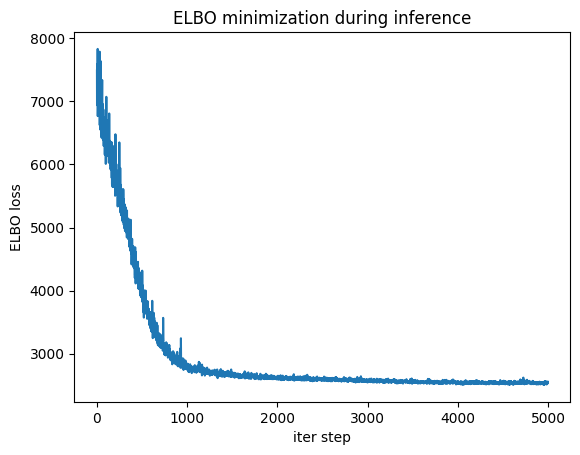

In [14]:
# this is for running the notebook in our testing framework
smoke_test = ('CI' in os.environ)
# the step was 2000
n_steps = 2 if smoke_test else 5000

# assert pyro.__version__.startswith('1.8.6')

# clear the param store in case we're in a REPL
pyro.clear_param_store()# setup the optimizer
# the learning rate was 0.0005 , "betas": (0.90, 0.999)
# tried "n_par":15 in adam params but it does not have this argument
adam_params = {"lr": 0.01}
optimizer = Adam(adam_params)
# setup the inference algorithm
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
# svi = SVI(model_gamma, guide_gamma, optimizer, loss=Trace_ELBO())

loss = []
pbar = tqdm(range(n_steps), position = 0)
# do gradient steps
for step in pbar:
    loss.append(torch.tensor(svi.step(data)))
    pbar.set_description("Mean ELBO %6.2f" % torch.tensor(loss[-20:]).mean())
    # for name, value in pyro.get_param_store().items():
    #     print(name, pyro.param(name))
    if torch.isnan(loss[-1]):
	    break

plt.figure()
plt.plot(loss)
plt.xlabel("iter step")
plt.ylabel("ELBO loss")
plt.title("ELBO minimization during inference")
plt.show()

In [23]:
for i in loss:
    print(i.numpy())

8341.038
6537.921
6487.0938
6860.363
6557.8296
6604.482
6826.914
6690.545
6917.8125
6638.9805
6779.63
6794.1396
6639.9883
6717.3755
6657.6343
6696.597
6447.6196
6638.3276
6598.9683
6638.22
6553.296
6736.06
6662.889
6459.404
6428.74
6514.0063
6543.6104
6398.0435
6819.874
6636.745
6563.9263
6607.0576
6663.7935
6664.863
6582.7065
6557.2676
6580.5146
6450.509
6458.801
6648.1274
6470.1753
6586.867
6674.061
6616.796
6516.22
6542.241
6533.3335
6453.199
6466.4595
6585.818
6475.537
6672.348
6481.769
6624.9
6640.212
6407.491
6454.793
6365.763
6623.0513
6408.6636
6394.7866
6465.4873
6490.3057
6446.4253
6524.1885
6376.6504
6498.127
6480.0054
6630.688
6533.8467
6545.438
6414.3857
6463.4756
6483.687
6481.447
6467.6294
6646.674
6407.441
6446.194
6487.9688
6416.1494
6374.7666
6547.653
6576.7466
6780.5234
6834.237
6416.6577
6368.2715
6418.4688
6456.342
6442.823
6562.025
6414.6665
6375.453
6369.8223
6375.882
6401.412
6549.308
6465.7505
6397.414
6495.525
6291.6104
6335.453
6400.444
6412.4023
6763.7256
62

In [15]:
pos_dict = {}
for name, value in pyro.get_param_store().items():
    pos_dict[name] = value

# change the dictionary to numpy instead of tensor
# because somehow the tensor cannot be save with pickle
numpy_dict = {key: value.detach().cpu().numpy() for key, value in pos_dict.items()}

In [120]:
df_indiv = pd.DataFrame(numpy_dict["m_locs"], columns=['sigma_rate', 'arctan_a', 'arctan_b', 'beta'])

In [121]:
df_mean = pd.DataFrame(numpy_dict["m"].reshape(1,4), columns=['sigma_rate', 'arctan_a', 'arctan_b', 'beta'])

In [122]:
df_indiv.to_csv("/home/yaning/Documents/Discounting/paper/results/arctan_indiv.csv", index=False)

In [123]:
df_mean.to_csv("/home/yaning/Documents/Discounting/paper/results/arctan_mean.csv", index=False)

In [16]:
# save the dictionary
with open('/home/yaning/Documents/Discounting/paper/results/boltzmann_tp.pkl', 'wb') as f:
    pickle.dump(numpy_dict, f)